In [ ]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Iterable, Tuple
import numpy as np
import pandas as pd

# from . import FeatureFn
# from ..utils import clean_xy, as_1d, get_first


dataset = pd.read_pickle(r"C:\Projects\260205_ACUTEVIS.pkl")




In [120]:
keys = dataset.keys()
print(keys)

SUBJECT_ID = "ACUTEVIS06"
SESSION_ID = "ses-04"
TASK_NAME = "task-gratings"

loco_trace = dataset.encoder.speed_mm.loc[SUBJECT_ID, SESSION_ID, TASK_NAME]
time = dataset.encoder.time_reference_s.loc[SUBJECT_ID, SESSION_ID, TASK_NAME]
print(loco_trace.shape)

MultiIndex([(       'suite2p',                   'cell_identifier'),
            (       'suite2p',                              'stat'),
            (       'suite2p',                               'ops'),
            (       'suite2p',                   'plane_directory'),
            (       'suite2p',                         'cell_mask'),
            (       'suite2p',                  'roi_fluorescence'),
            (       'suite2p',             'neuropil_fluorescence'),
            (       'suite2p',                          'deltaf_f'),
            (       'suite2p',                   'interp_deltaf_f'),
            (       'suite2p',                      'smoothed_dff'),
            (       'suite2p',              'interpolation_method'),
            (       'suite2p',                     'mean_fluo_dff'),
            (       'suite2p',                  'peaks_prominence'),
            (       'suite2p',              'num_peaks_prominence'),
            (       'suite2p',    

In [121]:
def _merge_gaps_by_time(
    segments: Iterable[Tuple[int, int]],
    t: np.ndarray,
    min_gap_s: float,
) -> list[Tuple[int, int]]:
    merged: list[Tuple[int, int]] = []
    for s, e in segments:
        if not merged:
            merged.append((s, e))
            continue
        ps, pe = merged[-1]
        gap = float(t[s] - t[pe])
        if gap <= min_gap_s:
            merged[-1] = (ps, e)
        else:
            merged.append((s, e))
    return merged


def _apply_min_duration_by_time(
    segments: Iterable[Tuple[int, int]],
    t: np.ndarray,
    min_duration_s: float,
) -> list[Tuple[int, int]]:
    dt = float(np.nanmedian(np.diff(t))) if t.size > 1 else 0.0
    keep = []
    for s, e in segments:
        duration = float(t[e] - t[s] + dt)
        if duration >= min_duration_s:
            keep.append((s, e))
    return keep

def _segments_from_mask(mask: np.ndarray) -> list[Tuple[int, int]]:
    idx = np.where(mask)[0]
    if idx.size == 0:
        return []
    segments = []
    start = idx[0]
    prev = idx[0]
    for i in idx[1:]:
        if i == prev + 1:
            prev = i
        else:
            segments.append((start, prev))
            start = i
            prev = i
    segments.append((start, prev))
    return segments

def _locomotion_bouts(
    t: np.ndarray,
    speed_cms: np.ndarray,
    *,
    min_speed_cms: float,
    min_duration_s: float,
    merge_gap_s: float,
) -> list[Tuple[int, int]]:
    mask = speed_cms >= min_speed_cms
    segments = _segments_from_mask(mask)
    if not segments:
        return []
    if merge_gap_s > 0:
        segments = _merge_gaps_by_time(segments, t, merge_gap_s)
    if min_duration_s > 0:
        segments = _apply_min_duration_by_time(segments, t, min_duration_s)
    return segments


def detect_locomotion_bouts(
    t: np.ndarray,
    speed_cms: np.ndarray,
    *,
    min_speed_cms: float = 0.2,
    min_duration_s: float = 1.0,
    merge_gap_s: float = 1.3,
) -> list[Tuple[int, int]]:
    """Detect locomotion bouts from a speed trace in cm/s."""
    return _locomotion_bouts(
        t,
        speed_cms,
        min_speed_cms=min_speed_cms,
        min_duration_s=min_duration_s,
        merge_gap_s=merge_gap_s,
    )


bouts = detect_locomotion_bouts(time, loco_trace)
print(bouts)

[(np.int64(46), np.int64(77)), (np.int64(129), np.int64(215)), (np.int64(229), np.int64(369)), (np.int64(382), np.int64(509)), (np.int64(1002), np.int64(1050)), (np.int64(1267), np.int64(1356)), (np.int64(1370), np.int64(1471)), (np.int64(1484), np.int64(2099)), (np.int64(3644), np.int64(3702)), (np.int64(3835), np.int64(3852))]


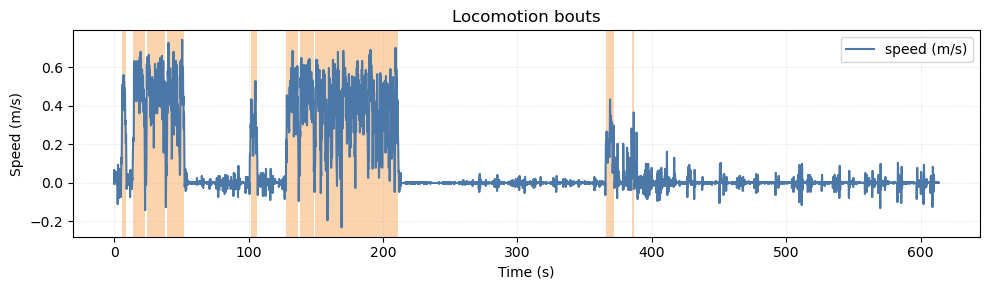

In [122]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))

ax.plot(time, loco_trace, color="#4C78A8", linewidth=1.5, label="speed (m/s)")
for start_idx, end_idx in bouts:
    ax.axvspan(
        time[start_idx],
        time[end_idx],
        ymin=0,
        ymax=1,
        color="#F58518",
        alpha=0.35,
        linewidth=0,
        zorder=0,)

ax.set_title("Locomotion bouts")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Speed (m/s)")
ax.grid(alpha=0.3, linestyle="--", linewidth=0.5)
ax.legend(loc="upper right")
plt.tight_layout()

In [89]:
def _segments_from_mask(mask: np.ndarray) -> list[Tuple[int, int]]:
    idx = np.where(mask)[0]
    if idx.size == 0:
        return []
    segments = []
    start = idx[0]
    prev = idx[0]
    for i in idx[1:]:
        if i == prev + 1:
            prev = i
        else:
            segments.append((start, prev))
            start = i
            prev = i
    segments.append((start, prev))
    return segments


def _merge_gaps_by_time(
    segments: Iterable[Tuple[int, int]],
    t: np.ndarray,
    min_gap_s: float,
) -> list[Tuple[int, int]]:
    merged: list[Tuple[int, int]] = []
    for s, e in segments:
        if not merged:
            merged.append((s, e))
            continue
        ps, pe = merged[-1]
        gap = float(t[s] - t[pe])
        if gap <= min_gap_s:
            merged[-1] = (ps, e)
        else:
            merged.append((s, e))
    return merged


def _apply_min_duration_by_time(
    segments: Iterable[Tuple[int, int]],
    t: np.ndarray,
    min_duration_s: float,
) -> list[Tuple[int, int]]:
    dt = float(np.nanmedian(np.diff(t))) if t.size > 1 else 0.0
    keep = []
    for s, e in segments:
        duration = float(t[e] - t[s] + dt)
        if duration >= min_duration_s:
            keep.append((s, e))
    return keep


def _locomotion_bouts(
    t: np.ndarray,
    speed_cms: np.ndarray,
    *,
    min_speed_cms: float,
    min_duration_s: float,
    merge_gap_s: float,
) -> list[Tuple[int, int]]:
    mask = speed_cms >= min_speed_cms
    segments = _segments_from_mask(mask)
    if not segments:
        return []
    if merge_gap_s > 0:
        segments = _merge_gaps_by_time(segments, t, merge_gap_s)
    if min_duration_s > 0:
        segments = _apply_min_duration_by_time(segments, t, min_duration_s)
    return segments


def detect_locomotion_bouts(
    t: np.ndarray,
    speed_cms: np.ndarray,
    *,
    min_speed_cms: float = 0.5,
    min_duration_s: float = 1.0,
    merge_gap_s: float = 0.5,
) -> list[Tuple[int, int]]:
    """Detect locomotion bouts from a speed trace in cm/s."""
    return _locomotion_bouts(
        t,
        speed_cms,
        min_speed_cms=min_speed_cms,
        min_duration_s=min_duration_s,
        merge_gap_s=merge_gap_s,
    )


def _bout_stats(
    t: np.ndarray,
    speed_cms: np.ndarray,
    bouts: Iterable[Tuple[int, int]],
) -> tuple[list[float], list[float], list[float]]:
    mean_speeds: list[float] = []
    distances_m: list[float] = []
    durations_s: list[float] = []
    dt_med = float(np.nanmedian(np.diff(t))) if t.size > 1 else 0.0
    for s, e in bouts:
        s = int(s)
        e = int(e)
        if e < s:
            continue
        duration = float(t[e] - t[s] + dt_med)
        durations_s.append(duration)
        mean_speeds.append(float(np.nanmean(np.abs(speed_cms[s : e + 1]))))
        if e == s:
            distances_m.append(0.0)
            continue
        dt = np.diff(t[s : e + 1])
        dist_cm = float(np.nansum(speed_cms[s + 1 : e + 1] * dt))
        distances_m.append(dist_cm / 100.0)
    return mean_speeds, distances_m, durations_s


@dataclass(frozen=True)
class MeanSpeedCMS(FeatureFn):
    name: str = "speed_mean_cms"
    label: str = "Speed (cm/s)"
    color: str = SOURCE_COLOR
    source: str = "treadmill"
    plotter: str = "boxplot"

    def _run_impl(self, row) -> float:
        t, spd_mm = clean_xy(
            get_first(row, [("treadmill", "time_elapsed_s"), ("encoder", "time_elapsed_s")]),
            get_first(row, [("treadmill", "speed_mm"), ("encoder", "speed")]),
        )
        if t is None:
            return np.nan
        return float(np.nanmean(spd_mm) / 10.0)


@dataclass(frozen=True)
class StdSpeedCMS(FeatureFn):
    name: str = "speed_std_cms"
    label: str = "Speed SD (cm/s)"
    color: str = SOURCE_COLOR
    source: str = "treadmill"

    def _run_impl(self, row) -> float:
        t, spd_mm = clean_xy(
            get_first(row, [("treadmill", "time_elapsed_s"), ("encoder", "time_elapsed_s")]),
            get_first(row, [("treadmill", "speed_mm"), ("encoder", "speed")]),
        )
        if t is None:
            return np.nan
        return float(np.nanstd(spd_mm) / 10.0)


@dataclass(frozen=True)
class TotalDistanceM(FeatureFn):
    name: str = "distance_m"
    label: str = "Distance (m)"
    color: str = SOURCE_COLOR
    source: str = "treadmill"
    plotter: str = "boxplot"

    def _run_impl(self, row) -> float:
        dist_mm = as_1d(get_first(row, [("treadmill", "distance_mm"), ("encoder", "distance")]))
        if dist_mm is not None and dist_mm.size >= 2:
            dist_mm = dist_mm[np.isfinite(dist_mm)]
            if dist_mm.size >= 2:
                return float((dist_mm[-1] - dist_mm[0]) / 1000.0)

        t, spd_mm = clean_xy(
            get_first(row, [("treadmill", "time_elapsed_s"), ("encoder", "time_elapsed_s")]),
            get_first(row, [("treadmill", "speed_mm"), ("encoder", "speed")]),
        )
        if t is None:
            return np.nan
        dt = np.diff(t)
        if dt.size == 0:
            return np.nan
        dt = np.clip(dt, 0, np.nanpercentile(dt, 99))
        return float(np.nansum(spd_mm[1:] * dt) / 1000.0)


@dataclass(frozen=True)
class LocomotionBoutFeature(FeatureFn):
    color: str = SOURCE_COLOR
    source: str = "treadmill"
    plotter: str = "boxplot"
    min_speed_cms: float = 5
    min_duration_s: float = 1.5
    merge_gap_s: float = 1.5

    def _get_bouts(self, row):
        t, spd_mm = clean_xy(
            get_first(row, [("treadmill", "time_elapsed_s"), ("encoder", "time_elapsed_s")]),
            get_first(row, [("treadmill", "speed_mm"), ("encoder", "speed")]),
        )
        if t is None:
            return None
        speed_cms = spd_mm / 10.0
        bouts = _locomotion_bouts(
            t,
            speed_cms,
            min_speed_cms=self.min_speed_cms,
            min_duration_s=self.min_duration_s,
            merge_gap_s=self.merge_gap_s,
        )
        return t, speed_cms, bouts


@dataclass(frozen=True)
class LocomotionBoutsCount(LocomotionBoutFeature):
    name: str = "locomotion_bouts_n"
    label: str = "Locomotion bouts (n)"

    def _run_impl(self, row) -> float:
        out = self._get_bouts(row)
        if out is None:
            return np.nan
        _, _, bouts = out
        return float(len(bouts))


@dataclass(frozen=True)
class LocomotionBoutSpeedMeanCMS(LocomotionBoutFeature):
    name: str = "locomotion_bout_speed_mean_cms"
    label: str = "Bout speed (cm/s)"

    def _run_impl(self, row) -> float:
        out = self._get_bouts(row)
        if out is None:
            return np.nan
        t, speed_cms, bouts = out
        if not bouts:
            return np.nan
        mean_speeds, _, _ = _bout_stats(t, speed_cms, bouts)
        return float(np.nanmean(mean_speeds)) if mean_speeds else np.nan


@dataclass(frozen=True)
class LocomotionBoutDistanceM(LocomotionBoutFeature):
    name: str = "locomotion_bout_distance_m"
    label: str = "Bout distance (m)"

    def _run_impl(self, row) -> float:
        out = self._get_bouts(row)
        if out is None:
            return np.nan
        t, speed_cms, bouts = out
        if not bouts:
            return np.nan
        _, distances_m, _ = _bout_stats(t, speed_cms, bouts)
        return float(np.nanmean(distances_m)) if distances_m else np.nan


@dataclass(frozen=True)
class LocomotionBoutDurationS(LocomotionBoutFeature):
    name: str = "locomotion_bout_duration_s"
    label: str = "Bout duration (s)"

    def _run_impl(self, row) -> float:
        out = self._get_bouts(row)
        if out is None:
            return np.nan
        t, speed_cms, bouts = out
        if not bouts:
            return np.nan
        _, _, durations_s = _bout_stats(t, speed_cms, bouts)
        return float(np.nanmean(durations_s)) if durations_s else np.nan

NameError: name 'FeatureFn' is not defined